## 1. Prepare bam files

```shell
indir="name_sort_bam"
outdir="deduped_bam"
mkdir -p ${outdir}

rm -f name_sort_bam_to_deduped.sh
for file in `ls ${indir}`; do
    outfile=${file/hisat3n_dna.all_reads.name_sort.bam/bam}
    echo "czip name_sort_bam_to_deduped -I ${indir}/${file} -O ${outdir}/${outfile} --env yap" >> name_sort_bam_to_deduped.sh
done;
cat name_sort_bam_to_deduped.sh | parallel -j 96
```

## 2. Benchmark: `bam_to_cz` vs `bam_to_allc`

Convert every deduped, position-sorted BAM under to both formats and compare **runtime** and **peak memory** per cell:

- `bam_to_allc` (ALLCools) &rarr; `benchmark/allc/<cell>.allc.tsv.gz`
- `bam_to_cz`   (cytozip)  &rarr; `benchmark/cz/<cell>.cz`

Each conversion runs as an isolated subprocess wrapped in `/usr/bin/time -f '%e %M'`
so the reported wall-clock and peak RSS are measured independently. Per-cell metrics
are written to `bam_benchmark.tsv` / `bam_benchmark.txt` and rendered as a grouped
barplot (`bam_benchmark.pdf`, modelled on the one in `2.dnam.ipynb`).

> Set `N_CELLS` in the config cell to a small number (e.g. `24`) for a quick,
> readable per-cell barplot; set it to `None` to process **all** BAM files.


In [1]:
import os,sys
os.chdir(os.path.expanduser("~/Projects/test_cytozip"))

In [2]:
! pwd

/anvil/projects/x-mcb130189/Wubin/test_cytozip


In [3]:
import os, sys, time, subprocess, random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

# ---- paths --------------------------------------------------------------
BAM_DIR  = Path("~/Projects/test_cytozip/deduped_bam").expanduser()
BASE     = Path("~/Projects/test_cytozip/benchmark").expanduser()
ALLC_DIR = BASE / "allc"          # bam_to_allc outputs
CZ_DIR   = BASE / "cz"            # bam_to_cz  outputs
REF_FA   = Path("~/Ref/hg38/hg38_ucsc_with_chrL.fa").expanduser()
REF_CZ   = Path("~/Ref/hg38/hg38_with_chrL.allc.cz").expanduser()
REF_CHROM_SIZE = Path("~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes").expanduser()
# czip build_ref -g ~/Ref/hg38/hg38_ucsc_with_chrL.fa -O ~/Ref/hg38/hg38_with_chrL.allc.cz -j 24 -s ~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes

for d in (ALLC_DIR, CZ_DIR, BASE):
    d.mkdir(parents=True, exist_ok=True)

# Srun 8 64 shared 3
# ---- run parameters -----------------------------------------------------
N_CELLS = 500        # None = ALL bam files; an int randomly samples N cells
SEED    = 0        # RNG seed so the random cell subset is reproducible
JOBS    = 1         # cells processed in parallel (each = 1 allc + 1 cz, serial)

PY       = sys.executable
TIME_BIN = "/usr/bin/time"

# make `samtools` discoverable to child subprocesses (ALLCools shells out to it)
os.environ["PATH"] = str(Path(PY).parent) + os.pathsep + os.environ.get("PATH", "")

bams = sorted(BAM_DIR.glob("*.bam"))
bams = sorted(random.Random(SEED).sample(bams, min(N_CELLS, len(bams))))
bams = bams[:N_CELLS]

assert REF_FA.exists() and Path(str(REF_FA) + ".fai").exists(), "reference FASTA / .fai missing"
assert REF_CZ.exists(), f"reference .cz missing: {REF_CZ}"
print(f"{len(bams)} bam files to benchmark (JOBS={JOBS})")
print(f"  allc -> {ALLC_DIR}")
print(f"  cz   -> {CZ_DIR}")


500 bam files to benchmark (JOBS=1)
  allc -> /home/x-wding2/Projects/test_cytozip/benchmark/allc
  cz   -> /home/x-wding2/Projects/test_cytozip/benchmark/cz


In [4]:
# from ALLCools._bam_to_allc import bam_to_allc
# %time bam_to_allc(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   reference_fasta=str(REF_FA), \
#                   output_path="UWA7648_CX1819_NAC_1_P10-1-K18-A10.allc.tsv.gz", \
#                   chrom_size=str(REF_CHROM_SIZE),\
#                   cpu=1,num_upstr_bases=0, num_downstr_bases=2, \
#                   min_mapq=10, min_base_quality=20)

# CPU times: user 2min 48s, sys: 11.6 s, total: 3min
# Wall time: 3min 15s

In [5]:
# from cytozip.bam import bam_to_cz
# %time bam_to_cz(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   genome=str(REF_FA), \
#                   output="UWA7648_CX1819_NAC_1_P10-1-K18-A10.cz", \
#                   reference=str(REF_CZ))

# CPU times: user 1min 18s, sys: 8.86 s, total: 1min 27s
# Wall time: 1min 29s                  

In [6]:
# ---- one isolated call per tool, timed with /usr/bin/time -----------------
_ALLC_CALL = (
    "from ALLCools._bam_to_allc import bam_to_allc; "
    "bam_to_allc(bam_path={bam!r}, reference_fasta={fa!r}, "
    "output_path={out!r}, chrom_size={chrom_size!r}, cpu=1, "
    "num_upstr_bases=0, num_downstr_bases=2, "
    "min_mapq=10, min_base_quality=20, compress_level=5)"
)
_CZ_CALL = (
    "from cytozip.bam import bam_to_cz; "
    "bam_to_cz(bam_path={bam!r}, genome={fa!r}, "
    "output={out!r}, mode='mc_cov', count_fmt='B', reference={ref!r}, "
    "min_mapq=10, min_base_quality=20)"
)


def _time_child(cmd):
    """Run `cmd` under /usr/bin/time; return {ok, wall_s, rss_mb, stderr_tail}."""
    wrapped = [TIME_BIN, "-f", "__TIME__ %e %M", "--"] + list(cmd)
    res = subprocess.run(wrapped, capture_output=True, text=True)
    wall_s, rss_mb = float("nan"), float("nan")
    for line in res.stderr.splitlines()[::-1]:
        if line.startswith("__TIME__"):
            _, w, m = line.split()
            wall_s, rss_mb = float(w), float(m) / 1024.0   # %M is peak RSS in KB
            break
    return dict(ok=res.returncode == 0, wall_s=wall_s, rss_mb=rss_mb,
                stderr_tail="\n".join(res.stderr.splitlines()[-8:]))


# ---- incremental per-cell log (appended the moment each cell finishes) -----
import threading

LOG_TSV = BASE / "bam_benchmark.log.tsv"
_LOG_COLS = ["cell", "bam_size_mb",
             "allc_ok", "allc_wall_s", "allc_rss_mb", "allc_size_mb",
             "cz_ok", "cz_wall_s", "cz_rss_mb", "cz_size_mb"]
_LOG_LOCK = threading.Lock()


def _append_log(row):
    """Thread-safe append of one cell's metrics to LOG_TSV (header written once)."""
    line = "\t".join(str(row.get(c, "")) for c in _LOG_COLS)
    with _LOG_LOCK:
        new = (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0
        with open(LOG_TSV, "a") as f:
            if new:
                f.write("\t".join(_LOG_COLS) + "\n")
            f.write(line + "\n")


def _load_log():
    """Load previously logged per-cell metrics as {cell: row_dict} (last wins)."""
    if (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0:
        return {}
    prev = pd.read_csv(LOG_TSV, sep="\t")
    return {r["cell"]: r.to_dict() for _, r in prev.iterrows()}


def bench_one(bam_path, prev_log=None):
    """Convert one BAM to allc + cz, timing each conversion in isolation.

    If both output files already exist (non-empty), skip the (re)conversion
    and reuse the previously logged metrics (falling back to on-disk sizes).
    """
    prev_log = prev_log or {}
    bam = Path(bam_path)
    cid = bam.name[:-4]                       # strip trailing ".bam"
    allc_out = ALLC_DIR / f"{cid}.allc.tsv.gz"
    cz_out   = CZ_DIR / f"{cid}.cz"

    # ---- skip if both outputs already exist ----
    if (allc_out.exists() and allc_out.stat().st_size > 0
            and cz_out.exists() and cz_out.stat().st_size > 0):
        row = dict(prev_log.get(cid, {}))
        row.update(cell=cid, bam_size_mb=bam.stat().st_size / 1e6,
                   allc_size_mb=allc_out.stat().st_size / 1e6,
                   cz_size_mb=cz_out.stat().st_size / 1e6)
        row.setdefault("allc_ok", True)
        row.setdefault("cz_ok", True)
        for k in ("allc_wall_s", "allc_rss_mb", "cz_wall_s", "cz_rss_mb"):
            row.setdefault(k, float("nan"))
        row.setdefault("allc_err", "")
        row.setdefault("cz_err", "")
        row["skipped"] = True
        return row

    # ---- run both conversions (start clean so sizes/timings reflect this run) ----
    for p in (allc_out, Path(str(allc_out) + ".tbi"), cz_out):
        if p.exists():
            p.unlink()

    r_a = _time_child([PY, "-c", _ALLC_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(allc_out), chrom_size=str(REF_CHROM_SIZE))])
    r_c = _time_child([PY, "-c", _CZ_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(cz_out), ref=str(REF_CZ))])

    row = dict(
        cell=cid,
        bam_size_mb=bam.stat().st_size / 1e6,
        allc_ok=r_a["ok"], allc_wall_s=r_a["wall_s"], allc_rss_mb=r_a["rss_mb"],
        allc_size_mb=(allc_out.stat().st_size / 1e6) if allc_out.exists() else 0.0,
        cz_ok=r_c["ok"], cz_wall_s=r_c["wall_s"], cz_rss_mb=r_c["rss_mb"],
        cz_size_mb=(cz_out.stat().st_size / 1e6) if cz_out.exists() else 0.0,
        allc_err=r_a["stderr_tail"], cz_err=r_c["stderr_tail"],
        skipped=False,
    )
    _append_log(row)   # persist this cell's metrics immediately
    return row


In [10]:
# bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P16-1-J7-D14.bam"
# prev_log = _load_log()
# bench_one(bam_path, prev_log=None)

In [ ]:
# ---- run the benchmark ----------------------------------------------------
prev_log = _load_log()          # reuse metrics for already-converted cells
t0 = time.perf_counter()
rows = []
with ThreadPoolExecutor(max_workers=JOBS) as ex:
    futs = {ex.submit(bench_one, str(b), prev_log): b for b in bams}
    for i, fut in enumerate(as_completed(futs), 1):
        r = fut.result()
        rows.append(r)
        if r.get("skipped"):
            tag = "SKIP"
        elif r["allc_ok"] and r["cz_ok"]:
            tag = "OK  "
        else:
            tag = "FAIL"
        print(f"[{i:>3}/{len(bams)}] {tag} {r['cell']:<40} "
              f"allc={r['allc_wall_s']:6.1f}s/{r['allc_rss_mb']:6.0f}MB  "
              f"cz={r['cz_wall_s']:6.1f}s/{r['cz_rss_mb']:6.0f}MB", flush=True)
        if tag == "FAIL":
            print("     allc_err:", r["allc_err"][-300:])
            print("     cz_err  :", r["cz_err"][-300:])
print(f"\ntotal wall-clock: {time.perf_counter() - t0:.1f}s")


[  1/500] OK   UWA7648_CX1819_NAC_1_P1-1-I3-A1          allc= 207.8s/   818MB  cz=  89.7s/  1168MB


[  2/500] OK   UWA7648_CX1819_NAC_1_P1-1-I3-A18         allc=  97.4s/   819MB  cz=  59.3s/  1170MB


[  3/500] OK   UWA7648_CX1819_NAC_1_P1-1-I3-A20         allc=  36.2s/   813MB  cz=  39.9s/  1164MB


[  4/500] OK   UWA7648_CX1819_NAC_1_P1-1-I3-A5          allc= 197.2s/   818MB  cz=  89.4s/  1168MB


[  5/500] OK   UWA7648_CX1819_NAC_1_P1-1-I3-B12         allc= 221.0s/   818MB  cz=  99.3s/  1167MB


...

[498/500] OK   UWA7648_CX1819_NAC_1_P9-1-M14-P20        allc= 171.4s/   818MB  cz=  80.1s/  1170MB


[499/500] OK   UWA7648_CX1819_NAC_1_P9-1-M14-P3         allc= 236.0s/   818MB  cz= 101.3s/  1189MB


[500/500] OK   UWA7648_CX1819_NAC_1_P9-1-M14-P9         allc= 160.1s/   819MB  cz=  79.6s/  1170MB



total wall-clock: 148501.6s
wrote /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.tsv


,cell,bam_size_mb,allc_ok,allc_wall_s,allc_rss_mb,allc_size_mb,cz_ok,cz_wall_s,cz_rss_mb,cz_size_mb,skipped,speedup,mem_ratio,size_ratio
0,UWA7648_CX1819_NAC_1_P1-1-I3-A1,175.44,True,207.81,818.36,102.41,True,89.72,1167.86,23.36,False,2.32,1.43,0.23
1,UWA7648_CX1819_NAC_1_P1-1-I3-A18,76.39,True,97.43,819.44,44.37,True,59.31,1170.38,12.13,False,1.64,1.43,0.27
2,UWA7648_CX1819_NAC_1_P1-1-I3-A20,11.89,True,36.25,812.58,7.16,True,39.89,1164.07,4.29,False,0.91,1.43,0.60
3,UWA7648_CX1819_NAC_1_P1-1-I3-A5,181.65,True,197.16,818.11,106.20,True,89.42,1168.32,23.97,False,2.20,1.43,0.23
4,UWA7648_CX1819_NAC_1_P1-1-I3-B12,212.91,True,220.99,817.88,123.10,True,99.33,1167.41,27.13,False,2.22,1.43,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,UWA7648_CX1819_NAC_1_P9-1-M14-M16,208.21,True,239.99,817.61,120.32,True,99.72,1173.82,26.61,False,2.41,1.44,0.22
496,UWA7648_CX1819_NAC_1_P9-1-M14-N12,344.77,True,404.55,815.20,210.73,True,159.89,1199.02,43.39,False,2.53,1.47,0.21
497,UWA7648_CX1819_NAC_1_P9-1-M14-P20,142.79,True,171.39,818.40,80.81,True,80.12,1169.68,19.01,False,2.14,1.43,0.24
498,UWA7648_CX1819_NAC_1_P9-1-M14-P3,209.62,True,235.98,817.91,123.38,True,101.29,1189.16,27.23,False,2.33,1.45,0.22


In [14]:
# ---- per-cell table -------------------------------------------------------
LOG_TSV = BASE / "bam_benchmark.log.tsv"
if LOG_TSV.exists() and LOG_TSV.stat().st_size > 0:
    # reuse the incrementally-written per-cell log instead of rebuilding from rows
    df = pd.read_csv(LOG_TSV, sep="\t").sort_values("cell").reset_index(drop=True)
    print("read", LOG_TSV)
else:
    df = pd.DataFrame(sorted(rows, key=lambda r: r["cell"]))
    df = df.drop(columns=["allc_err", "cz_err"], errors="ignore")

df["speedup"]    = df["allc_wall_s"] / df["cz_wall_s"]
df["mem_ratio"]  = df["cz_rss_mb"]   / df["allc_rss_mb"]
df["size_ratio"] = df["cz_size_mb"]  / df["allc_size_mb"]

tsv = BASE / "bam_benchmark.tsv"
df.to_csv(tsv, sep="\t", index=False, float_format="%.4f")
print("wrote", tsv)
df.round(2)

read /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.log.tsv
wrote /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.tsv


,cell,bam_size_mb,allc_ok,allc_wall_s,allc_rss_mb,allc_size_mb,cz_ok,cz_wall_s,cz_rss_mb,cz_size_mb,speedup,mem_ratio,size_ratio
0,UWA7648_CX1819_NAC_1_P1-1-I3-A1,175.44,True,207.81,818.36,102.41,True,89.72,1167.86,23.36,2.32,1.43,0.23
1,UWA7648_CX1819_NAC_1_P1-1-I3-A18,76.39,True,97.43,819.44,44.37,True,59.31,1170.38,12.13,1.64,1.43,0.27
2,UWA7648_CX1819_NAC_1_P1-1-I3-A20,11.89,True,36.25,812.58,7.16,True,39.89,1164.07,4.29,0.91,1.43,0.60
3,UWA7648_CX1819_NAC_1_P1-1-I3-A5,181.65,True,197.16,818.11,106.20,True,89.42,1168.32,23.97,2.20,1.43,0.23
4,UWA7648_CX1819_NAC_1_P1-1-I3-B12,212.91,True,220.99,817.88,123.10,True,99.33,1167.41,27.13,2.22,1.43,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,UWA7648_CX1819_NAC_1_P9-1-M14-M16,208.21,True,239.99,817.61,120.32,True,99.72,1173.82,26.61,2.41,1.44,0.22
496,UWA7648_CX1819_NAC_1_P9-1-M14-N12,344.77,True,404.55,815.20,210.73,True,159.89,1199.02,43.39,2.53,1.47,0.21
497,UWA7648_CX1819_NAC_1_P9-1-M14-P20,142.79,True,171.39,818.40,80.81,True,80.12,1169.68,19.01,2.14,1.43,0.24
498,UWA7648_CX1819_NAC_1_P9-1-M14-P3,209.62,True,235.98,817.91,123.38,True,101.29,1189.16,27.23,2.33,1.45,0.22


In [17]:
# ---- aggregate summary written to a text file -----------------------------
tot_at, tot_ct = df["allc_wall_s"].sum(), df["cz_wall_s"].sum()
max_arss, max_crss = df["allc_rss_mb"].max(), df["cz_rss_mb"].max()
mean_arss, mean_crss = df["allc_rss_mb"].mean(), df["cz_rss_mb"].mean()
tot_as, tot_cs = df["allc_size_mb"].sum(), df["cz_size_mb"].sum()

txt = BASE / "bam_benchmark.txt"
txt.write_text(
    "cytozip bam_to_cz  vs  ALLCools bam_to_allc\n"
    "============================================\n"
    f"reference FASTA : {REF_FA}\n"
    f"reference .cz   : {REF_CZ}\n"
    f"cells           : {len(df)}\n"
    "\n"
    f"ALLCools : time={tot_at:9.1f} s   peak_rss(max)={max_arss:7.1f} MB   "
    f"mean_rss={mean_arss:7.1f} MB   size={tot_as:8.1f} MB\n"
    f"cytozip  : time={tot_ct:9.1f} s   peak_rss(max)={max_crss:7.1f} MB   "
    f"mean_rss={mean_crss:7.1f} MB   size={tot_cs:8.1f} MB\n"
    "\n"
    f"speedup   (allc / cz  time)      = {tot_at / max(tot_ct, 1e-9):5.2f}x\n"
    f"memory    (cz / allc  mean rss)  = {mean_crss / max(mean_arss, 1e-9) * 100:5.1f}%\n"
    f"compress  (cz / allc  size)      = {tot_cs / max(tot_as, 1e-9) * 100:5.1f}%\n"
)
print(txt.read_text())


cytozip bam_to_cz  vs  ALLCools bam_to_allc
reference FASTA : /home/x-wding2/Ref/hg38/hg38_ucsc_with_chrL.fa
reference .cz   : /home/x-wding2/Ref/hg38/hg38_with_chrL.allc.cz
cells           : 500

ALLCools : time= 102933.1 s   peak_rss(max)=  823.1 MB   mean_rss=  817.6 MB   size= 53227.4 MB
cytozip  : time=  45817.8 s   peak_rss(max)= 1222.2 MB   mean_rss= 1173.3 MB   size= 11955.0 MB

speedup   (allc / cz  time)      =  2.25x
memory    (cz / allc  mean rss)  = 143.5%
compress  (cz / allc  size)      =  22.5%



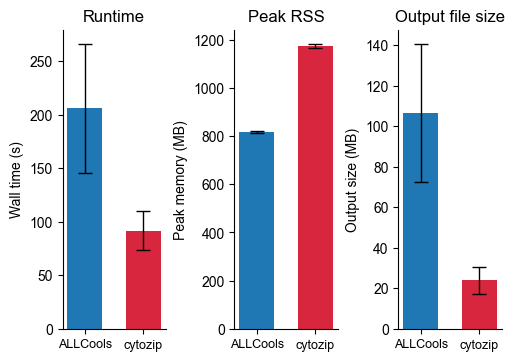

In [21]:
# ---- barplot: average runtime, peak memory & output size (mean +/- SD) -----
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

d = df.copy()
n = len(d)
c_allc, c_cz = '#1f77b4', '#d7263d'
x = np.arange(2)                       # two tools per panel

metrics = [
    ('allc_wall_s', 'cz_wall_s',  'Wall time (s)',      'Runtime'),
    ('allc_rss_mb', 'cz_rss_mb',  'Peak memory (MB)',   'Peak RSS'),
    ('allc_size_mb', 'cz_size_mb', 'Output size (MB)',  'Output file size'),
]

fig, axes = plt.subplots(1, 3, figsize=(5, 3.5), constrained_layout=True)

for ax, (a_col, c_col, ylabel, title) in zip(axes, metrics):
    means = [d[a_col].mean(), d[c_col].mean()]
    sds   = [d[a_col].std(),  d[c_col].std()]
    ax.bar(x, means, yerr=sds, capsize=5, color=[c_allc, c_cz],
           width=0.6, error_kw=dict(ecolor='black', lw=1))
    ax.set_xticks(x)
    ax.set_xticklabels(['ALLCools', 'cytozip'], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

tot_at, tot_ct = d['allc_wall_s'].sum(), d['cz_wall_s'].sum()
tot_as, tot_cs = d['allc_size_mb'].sum(), d['cz_size_mb'].sum()
# fig.suptitle(
#     f'BAM \u2192 ALLC vs BAM \u2192 CZ\n(n={n} cells, mean \u00b1 SD)   '
#     f'time: {tot_at:.0f} \u2192 {tot_ct:.0f} s '
#     f'({tot_at / max(tot_ct, 1e-9):.2f}\u00d7 faster)   '
#     f'mean RSS: {d["allc_rss_mb"].mean():.0f} \u2192 {d["cz_rss_mb"].mean():.0f} MB   '
#     f'size: {tot_as:.0f} \u2192 {tot_cs:.0f} MB '
#     f'({tot_cs / max(tot_as, 1e-9) * 100:.1f}%)',
#     fontsize=10,
# )

fig.savefig(BASE / 'bam_benchmark.pdf', bbox_inches='tight')
plt.show()


## 3. Validate: do `allc` and `cz` store the same values?

Cross-check the per-cell outputs in `benchmark/allc` (ALLCools) against
`benchmark/cz` (cytozip) to confirm they carry **identical methylation calls**.

Comparison rules (matching how each file stores data):

- **cz** is written in `mode='mc_cov'`, so it keeps only `[mc, cov]` aligned
  1:1 with the reference `.cz` positions. We recover coordinates from
  `REF_CZ` and **drop records with `cov == 0`** before comparing.
- **cz** stores counts as `uint8` (`count_fmt='B'`), so any `mc`/`cov` in the
  `allc` file is **clipped to 255** before comparison.
- ALLCools `bam_to_allc` has a known bug: the **last cytosine of every
  chromosome is dropped**. cz-only sites that fall on each chromosome's last
  reference position are therefore expected and reported separately (grey bar),
  not counted as real discrepancies.

We merge on `(chrom, pos)`, tally agreements/disagreements, and visualize the
result (`allc_vs_cz_comparison.pdf`).


In [22]:
# ---- helpers to load allc / cz records for value comparison ---------------
import numpy as np
from cytozip.cz import Reader
from cytozip.bam import _LazyRefPositions

# cz stores mc/cov as uint8 ('B'), so allc values must be clipped to 255
# before comparison; the cz file (mode='mc_cov') keeps only [mc, cov] aligned
# 1:1 with the reference .cz positions, so we recover coordinates from REF_CZ.
COUNT_MAX = 255


def load_allc(allc_path):
    """Read an ALLCools .allc.tsv.gz into (chrom, pos, mc_allc, cov_allc).

    mc / cov are clipped to COUNT_MAX (255) to match cz's uint8 storage.
    """
    a = pd.read_csv(
        allc_path, sep="\t", header=None, usecols=[0, 1, 4, 5],
        names=["chrom", "pos", "mc_allc", "cov_allc"],
        dtype={"chrom": str, "pos": np.int64,
               "mc_allc": np.int64, "cov_allc": np.int64},
    )
    a["mc_allc"] = a["mc_allc"].clip(upper=COUNT_MAX)
    a["cov_allc"] = a["cov_allc"].clip(upper=COUNT_MAX)
    return a


def load_cz_covered(cz_path, refpos):
    """Read a mode='mc_cov' cz into (chrom, pos, mc_cz, cov_cz), cov>0 only.

    Positions come from the row-aligned reference (`refpos`); records with
    cov==0 are dropped so the result matches ALLCools' covered-sites-only
    output. Also returns {chrom: last_ref_pos} so the caller can recognise
    the ALLCools "last cytosine of each chromosome is missing" bug.
    """
    cell = Reader(str(cz_path))
    frames, last_pos = [], {}
    for dim in cell.chunk_key2offset.keys():
        chrom = dim[-1]
        arr = cell.chunk2numpy(dim)          # f0=mc, f1=cov (uint8)
        mc, cov = arr["f0"], arr["f1"]
        pos = refpos.get(chrom)              # uint32, row-aligned with mc/cov
        if pos is None:
            continue
        if len(pos) != len(mc):
            raise ValueError(
                f"{cz_path} chrom {chrom}: {len(mc)} records but reference "
                f"has {len(pos)} positions (not row-aligned).")
        last_pos[chrom] = int(pos[-1]) if len(pos) else -1
        keep = cov > 0
        frames.append(pd.DataFrame({
            "chrom": chrom,
            "pos": pos[keep].astype(np.int64),
            "mc_cz": mc[keep].astype(np.int64),
            "cov_cz": cov[keep].astype(np.int64),
        }))
        refpos.drop(chrom)                   # release this chrom's ref pages
    cell.close()
    cz = (pd.concat(frames, ignore_index=True) if frames
          else pd.DataFrame(columns=["chrom", "pos", "mc_cz", "cov_cz"]))
    return cz, last_pos


# ---- pick a few cells that have BOTH an allc and a cz output --------------
N_COMPARE = 3
CMP_CIDS = []
for p in sorted(CZ_DIR.glob("*.cz")):
    cid = p.name[:-3]
    if (ALLC_DIR / f"{cid}.allc.tsv.gz").exists():
        CMP_CIDS.append(cid)
CMP_CIDS = CMP_CIDS[:N_COMPARE]
print(f"will compare {len(CMP_CIDS)} cells:")
for cid in CMP_CIDS:
    print("  ", cid)


will compare 3 cells:
   UWA7648_CX1819_NAC_1_P1-1-I3-A1
   UWA7648_CX1819_NAC_1_P1-1-I3-A18
   UWA7648_CX1819_NAC_1_P1-1-I3-A20


In [23]:
# ---- run the comparison over a few cells ----------------------------------
# For every compared cell we outer-merge the ALLCools allc records against the
# cytozip cz records (cov>0, mc/cov clipped to 255) on (chrom, pos) and tally:
#   * matched sites + how many disagree on mc / cov
#   * cz-only sites  -> split into the *expected* ALLCools last-C-of-chrom bug
#                       vs. any *other* (unexpected) cz-only site
#   * allc-only sites (allc has a covered site cz's cov>0 set lacks)
refpos = _LazyRefPositions(str(REF_CZ))     # streamed uint32 ref positions
summaries      = []
matched_frames = []
SAMPLE_PER_CELL = 200_000                   # subsample matched sites for plots
_rng = np.random.default_rng(0)

for cid in CMP_CIDS:
    a = load_allc(ALLC_DIR / f"{cid}.allc.tsv.gz")
    c, last_pos = load_cz_covered(CZ_DIR / f"{cid}.cz", refpos)

    m = a.merge(c, on=["chrom", "pos"], how="outer", indicator=True)
    m["last_pos"] = m["chrom"].map(last_pos)

    both      = m["_merge"] == "both"
    cz_only   = m["_merge"] == "right_only"
    allc_only = m["_merge"] == "left_only"
    cz_only_lastC = cz_only & (m["pos"] == m["last_pos"])

    b = m.loc[both]
    mc_mismatch  = int((b["mc_allc"]  != b["mc_cz"]).sum())
    cov_mismatch = int((b["cov_allc"] != b["cov_cz"]).sum())

    summaries.append(dict(
        cell=cid,
        n_allc=int(len(a)),
        n_cz_cov_pos=int(len(c)),
        n_both=int(both.sum()),
        mc_mismatch=mc_mismatch,
        cov_mismatch=cov_mismatch,
        cz_only_lastC=int(cz_only_lastC.sum()),
        cz_only_other=int((cz_only & ~cz_only_lastC).sum()),
        allc_only=int(allc_only.sum()),
    ))

    keep = b[["mc_allc", "mc_cz", "cov_allc", "cov_cz"]]
    if len(keep) > SAMPLE_PER_CELL:
        idx = _rng.choice(len(keep), SAMPLE_PER_CELL, replace=False)
        keep = keep.iloc[idx]
    matched_frames.append(keep)

refpos.close()

cmp_df  = pd.DataFrame(summaries)
matched = pd.concat(matched_frames, ignore_index=True)

# concordance rate on matched sites (both mc and cov identical)
cmp_df["concordant"] = cmp_df["n_both"] - cmp_df["mc_mismatch"] - cmp_df["cov_mismatch"]
cmp_df["concord_pct"] = 100.0 * cmp_df["concordant"] / cmp_df["n_both"].clip(lower=1)

print(f"compared {len(cmp_df)} cells; "
      f"{int(cmp_df['n_both'].sum()):,} matched sites total")
cmp_df


compared 3 cells; 21,140,643 matched sites total


,cell,n_allc,n_cz_cov_pos,n_both,mc_mismatch,cov_mismatch,cz_only_lastC,cz_only_other,allc_only,concordant,concord_pct
0,UWA7648_CX1819_NAC_1_P1-1-I3-A1,26298927,26575175,14120679,527641,912002,0,12454496,12178248,12681036,89.804718
1,UWA7648_CX1819_NAC_1_P1-1-I3-A18,11408770,11904048,6048748,108383,334364,0,5855300,5360022,5606001,92.680353
2,UWA7648_CX1819_NAC_1_P1-1-I3-A20,1873984,1955638,971216,4712,31172,0,984422,902768,935332,96.305250


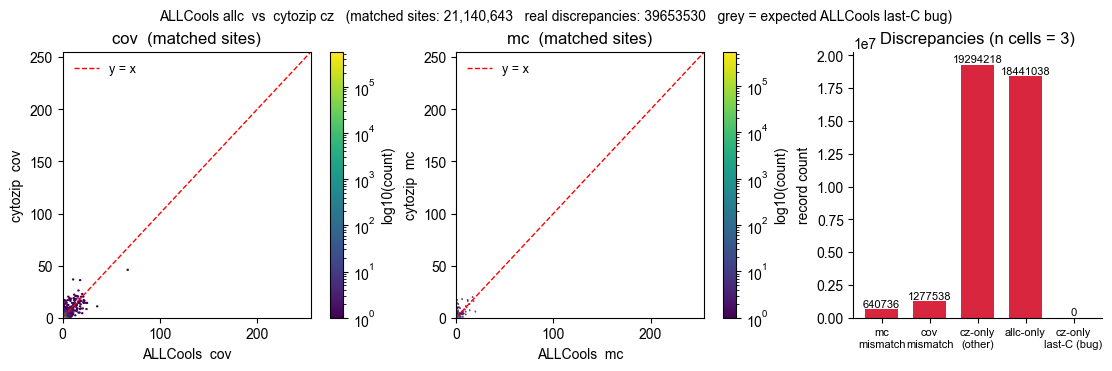

In [24]:
# ---- visualize the allc-vs-cz value comparison ----------------------------
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)

# --- panel 1 & 2: matched-record agreement (should lie exactly on y = x) ---
for ax, a_col, z_col, title in [
    (axes[0], 'cov_allc', 'cov_cz', 'cov  (matched sites)'),
    (axes[1], 'mc_allc',  'mc_cz',  'mc  (matched sites)'),
]:
    hb = ax.hexbin(matched[a_col], matched[z_col], gridsize=60,
                   bins='log', cmap='viridis', mincnt=1)
    lim = 255
    ax.plot([0, lim], [0, lim], color='red', lw=1, ls='--', label='y = x')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(f'ALLCools  {a_col.split("_")[0]}')
    ax.set_ylabel(f'cytozip  {z_col.split("_")[0]}')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    fig.colorbar(hb, ax=ax, label='log10(count)')

# --- panel 3: discrepancy breakdown (summed over compared cells) -----------
agg = cmp_df[['mc_mismatch', 'cov_mismatch', 'cz_only_other',
              'allc_only', 'cz_only_lastC']].sum()
labels = ['mc\nmismatch', 'cov\nmismatch', 'cz-only\n(other)',
          'allc-only', 'cz-only\nlast-C (bug)']
colors = ['#d7263d', '#d7263d', '#d7263d', '#d7263d', '#999999']
ax = axes[2]
bars = ax.bar(range(len(agg)), agg.values, color=colors, width=0.7)
ax.set_xticks(range(len(agg)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('record count')
ax.set_title('Discrepancies (n cells = %d)' % len(cmp_df))
for b, v in zip(bars, agg.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v)}',
            ha='center', va='bottom', fontsize=8)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

n_both_tot = int(cmp_df['n_both'].sum())
n_realmis = int(agg[['mc_mismatch', 'cov_mismatch',
                     'cz_only_other', 'allc_only']].sum())
fig.suptitle(
    f'ALLCools allc  vs  cytozip cz   '
    f'(matched sites: {n_both_tot:,}   real discrepancies: {n_realmis}   '
    f'grey = expected ALLCools last-C bug)',
    fontsize=10,
)

fig.savefig(BASE / 'allc_vs_cz_comparison.pdf', bbox_inches='tight')
plt.show()
